In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1,Normalize
from model.model import myInformer
from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from tqdm import tqdm

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 0
d_ff= 2048
E_LAYERS = 2
D_LAYERS = 1
PRED_LEN =24
FEATURES= 4
TIME_FEATURES = 3
EPOCHS = 15
EMBED_FREQ = 'r'
DATA_SOURCE = 'GAS'
settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff, 'e_layer': E_LAYERS,
            'd_layer':D_LAYERS, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES, 'freq':EMBED_FREQ,
            'data_source':DATA_SOURCE}
# print(settings)
# Creation du model Exp
myExpFct = Exp(settings)
myExpFct.build(split=0.2)
myExpFct._buildModel(0.000_15)
model = myExpFct.train(EPOCHS)

Epoch: 0 -> loss=16.49/0.36 -> Accuracy=52.36%/91.68% - [95.84s]
Epoch: 1 -> loss=1.79/0.29 -> Accuracy=65.94%/92.86% - [93.23s]
Epoch: 2 -> loss=0.93/0.31 -> Accuracy=72.42%/92.39% - [90.77s]
Epoch: 3 -> loss=0.56/0.31 -> Accuracy=76.50%/92.28% - [87.40s]
Epoch: 4 -> loss=0.38/0.32 -> Accuracy=79.38%/92.02% - [99.30s]
Epoch: 5 -> loss=0.31/0.29 -> Accuracy=81.48%/92.63% - [91.06s]
Epoch: 6 -> loss=0.25/0.27 -> Accuracy=83.12%/93.00% - [89.14s]
Epoch: 7 -> loss=0.21/0.24 -> Accuracy=84.41%/93.38% - [86.71s]
Epoch: 8 -> loss=0.20/0.23 -> Accuracy=85.43%/93.62% - [83.55s]
Epoch: 9 -> loss=0.17/0.24 -> Accuracy=86.30%/93.46% - [85.91s]
Epoch:10 -> loss=0.14/0.23 -> Accuracy=87.09%/93.44% - [85.51s]
Epoch:11 -> loss=0.15/0.22 -> Accuracy=87.72%/93.59% - [85.23s]
Epoch:12 -> loss=0.14/0.21 -> Accuracy=88.29%/93.71% - [85.14s]
Epoch:13 -> loss=0.12/0.21 -> Accuracy=88.80%/93.88% - [89.33s]
Epoch:14 -> loss=0.11/0.20 -> Accuracy=89.25%/94.05% - [85.07s]
Total time taken: 1333.3s


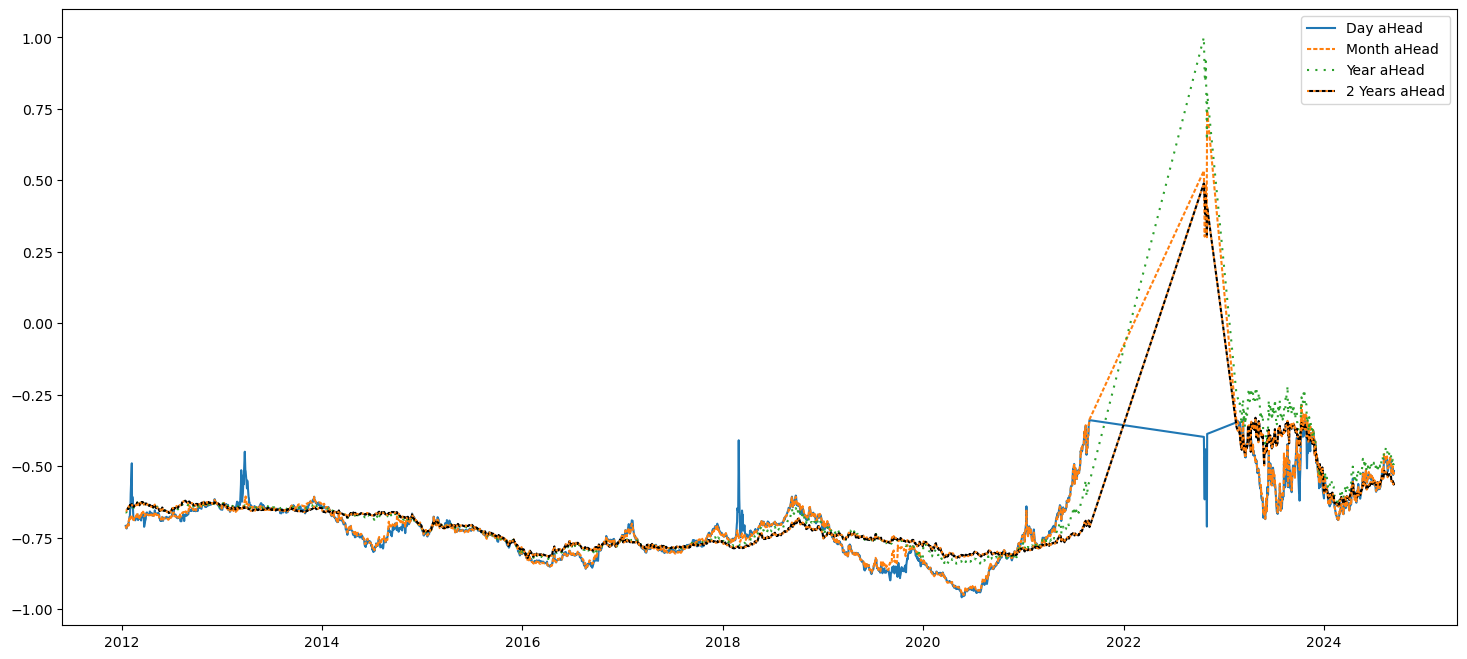

In [3]:
myExpFct.dataFct.displayNorm()
# print(myExpFct.dataFct.df_Data['sJour'].describe())

Saved checkpoint


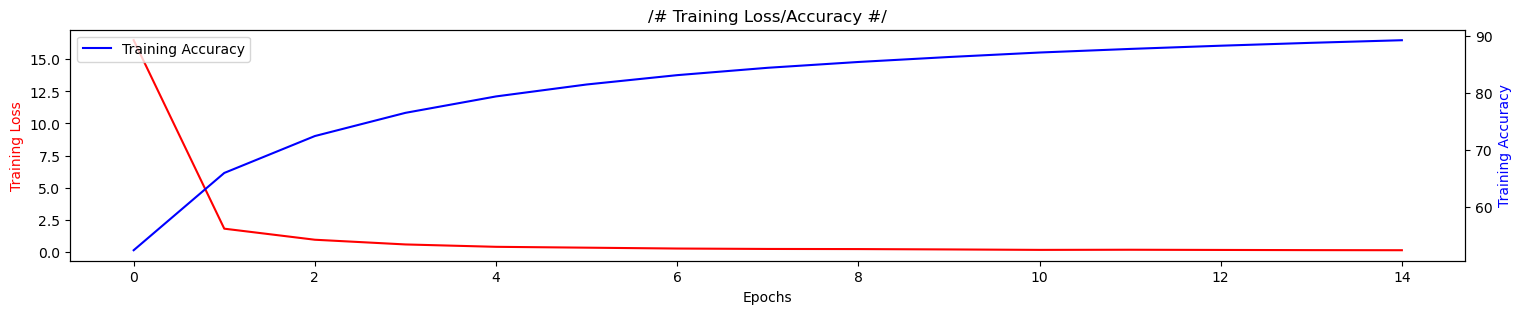

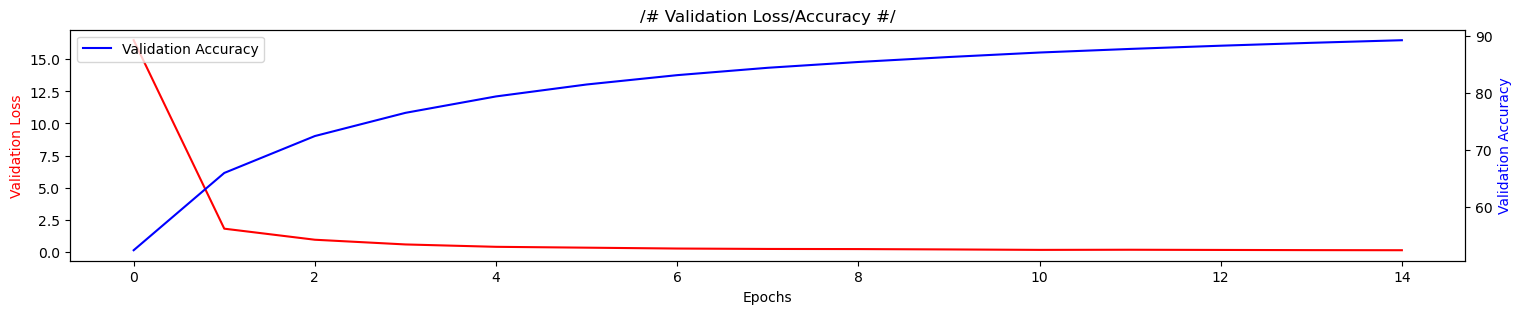

In [4]:
# SAVE MODEL
# from tensorflow import train
# # Create a checkpoint object and manager to manage multiple checkpoints
# ckpt = train.Checkpoint(model=myExpFct.modelFct, optimizer=myExpFct.optimizer)
# ckpt_manager = train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=3)
# # Save a checkpoint after every five epochs
# save_path = ckpt_manager.save()
# print("Saved checkpoint")
# # Save the trained model weights
# myExpFct.modelFct.save_weights("weights/wghts" + str(EPOCHS) + ".ckpt")
myExpFct.save_model()
myExpFct.drawTrain()
myExpFct.drawValid()


In [5]:
def getData(data,init,seq_len=96,pred_len=24):
    f = 4
    dec_len = seq_len//2
    dec_all = dec_len + pred_len
    Xe = data[init:init+seq_len,0:f]
    Xed = data[init:init+seq_len,f:]
    padd = tf.zeros((pred_len,f))
    Xd = tf.concat([data[init+dec_len:init+seq_len,:f],padd[:,:f]],axis=0)
    Xdd = data[init+dec_len:init+dec_len+dec_all,f:]
    Xe = tf.reshape(Xe, shape=(1,seq_len,f))
    Xed = tf.reshape(Xed, shape=(1,seq_len,3))
    Xd = tf.reshape(Xd, shape=(1,dec_all,f))
    Xdd = tf.reshape(Xdd, shape=(1,dec_all,3))
    Xr = data[init:init+seq_len,:f]
    Xr = tf.reshape(Xr, shape=(seq_len,f))
    return Xe,Xed,Xd,Xdd,Xr


In [19]:
# # Creation du model Exp
# myExpFct = Exp(settings)
# myExpFct.build()
# # Chargement du model
# new_modelExp = Exp(settings=settings)
# new_model = new_modelExp.modelFct
# new_model.load_weights('weights/wghts20.ckpt')

new_model = myExpFct.modelFct

# Prédictions ...
init = 2220
features = 4
forecast = 500

data = myExpFct.dataFct.dataN
_,_,_,_,Xi = getData(data,init,96,24)
Xi = Xi[:,:]
Pi = tf.cast(Xi,tf.float32)
Pimin = Pi
Pimax = Pi
Pia = Pi
Pall = Pi
Mall = Pi[None,-24:,:]
infM = tf.ones(shape=(1,1,features),dtype=tf.float32) * -1.e10
infm = tf.ones(shape=(1,1,features),dtype=tf.float32) * 1.e10
# for i in (range (forecast)):
for i in tqdm(range (init, init+forecast)):
    Xe,Xed,Xd,Xdd,Xr = getData(data,i+1,96,24)
    pred = new_model(Xe,Xed,Xd, Xdd, training=False)[0]
    predAll = tf.cast(tf.reshape(pred,shape=(PRED_LEN,features)),tf.float32)
    Mall = tf.concat([Mall,pred],axis=0)
    # L,F = Pi.shape
    Li,F = Pia.shape
    # compute min/max
    cM=tf.concat([Pimax[None,-23:,:],infM],axis=1)
    cm=tf.concat([Pimin[None,-23:,:],infm],axis=1)
    bM = tf.concat([pred,cM],axis=0)
    bm = tf.concat([pred,cm],axis=0)
    bmax= tf.reduce_max(bM,axis=0)
    bmin= tf.reduce_min(bm,axis=0)
    Pimax = tf.concat([Pimax[:Li-23,:],bmax],axis=0)
    Pimin = tf.concat([Pimin[:Li-23,:],bmin],axis=0)
    Xi = tf.concat([Xi,Xr[None,-1,:]],axis=0)
    # Pi = tf.concat([Pi,predOne],axis=0)
    Pia = tf.concat([Pia[:Li-23,:],predAll],axis=0)

# L,F = Pi.shape
Li,F = Pia.shape
# Pi = myExpFct.scaler.inverse_transform(tf.reshape(Pi,shape=(L,F)))
PCia = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pia,shape=(Li,F)))
PCimax = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimax,shape=(Li,F)))
PCimin = myExpFct.dataFct.scalerData.inverse_transform(tf.reshape(Pimin,shape=(Li,F)))
# x_padd = tf.zeros(shape=(48,7))
# pred = tf.concat([x_padd,pred],axis=0)
# print(pred.shape)

x_ = myExpFct.dataFct.scalerData.inverse_transform(Xi)
df_raw = myExpFct.dataFct.df_Data

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:48<00:00, 10.32it/s]


In [22]:
print(PCia.shape)
print(myExpFct.dataFct.dataN.shape)
print(Mall.shape)
# print(x_)

(596, 4)
(2846, 7)
(501, 24, 4)


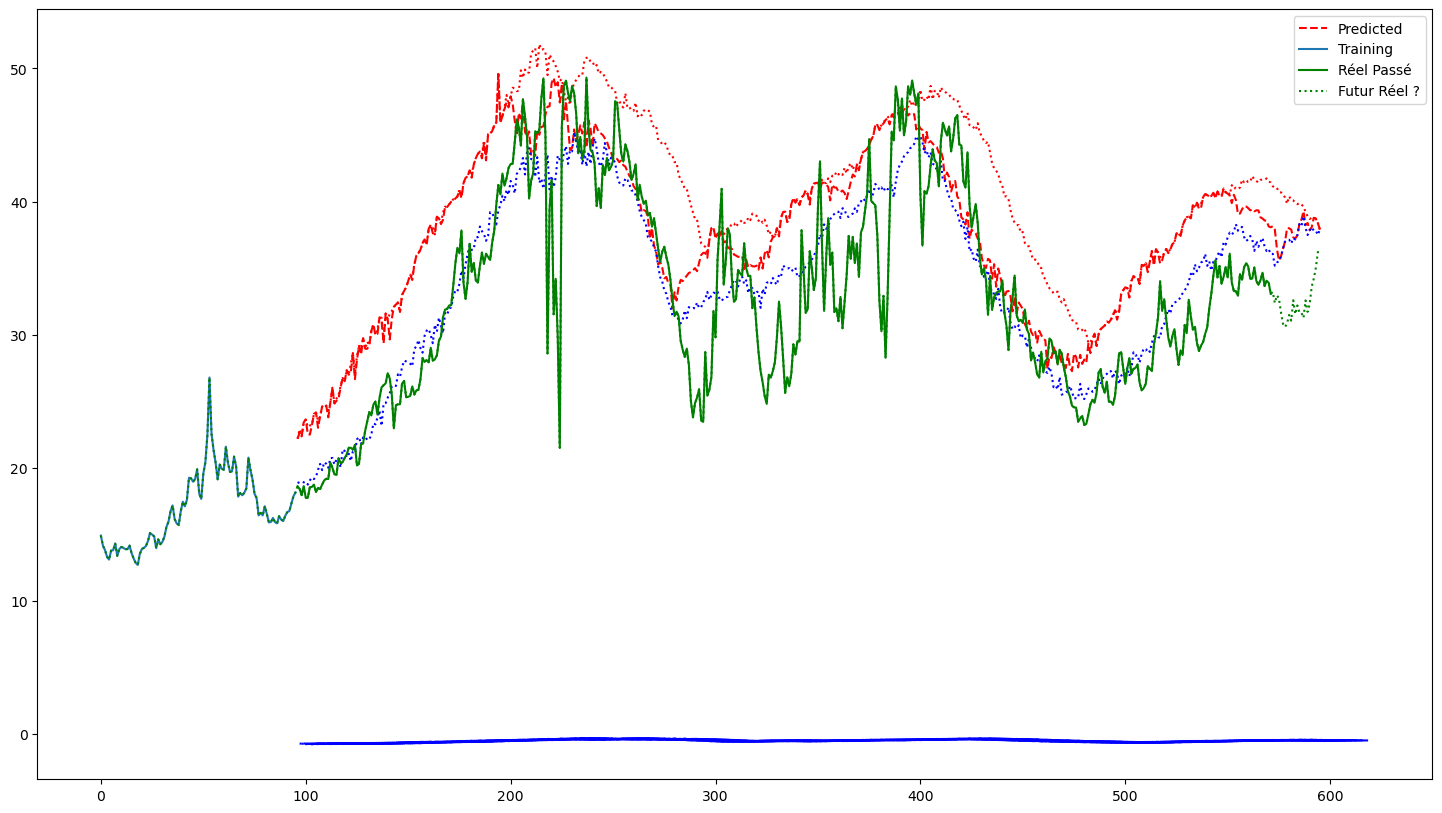

In [23]:
#  0----------48----72----96----120
sel_feature=0

# v_min = math.ceil( tf.reduce_min(x_[:,sel_feature]) / 10.) * 10. - 10.
# v_max = math.floor( (math.ceil( tf.reduce_max(x_[:,sel_feature])/10.) * 10) )

deb = 48 +1 + forecast
fin = 72 + forecast + 24

fig = plt.figure(figsize=(18,10))
# plt.ylim(0, 300 )

plt.plot(range(96, fin),PCia[96:fin,sel_feature], 'r--', label="Predicted");
plt.plot(range(96, fin),PCimax[96:fin,sel_feature], 'r:');
plt.plot(range(96, fin),PCimin[96:fin,sel_feature], 'b:');
# plt.fill_between(x=range(0,fin), y1=PCimax[:,6], y2=PCimin[:,6], alpha=0.10, color='tab:orange')
plt.plot(range(0,96),x_[0:96,sel_feature], label="Training");
plt.plot(range(96,fin-24),x_[96:fin-24,sel_feature], 'g', label="Réel Passé");
plt.plot(range(0,fin),myExpFct.dataFct.data[init:fin+init,sel_feature], 'g:', label="Futur Réel ?");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
# for i in range(1,forecast+1):
#     plt.plot(range(96+i,96+24+i),Mall[i,:,sel_feature], 'b:')
plt.legend();

(501, 24, 4)


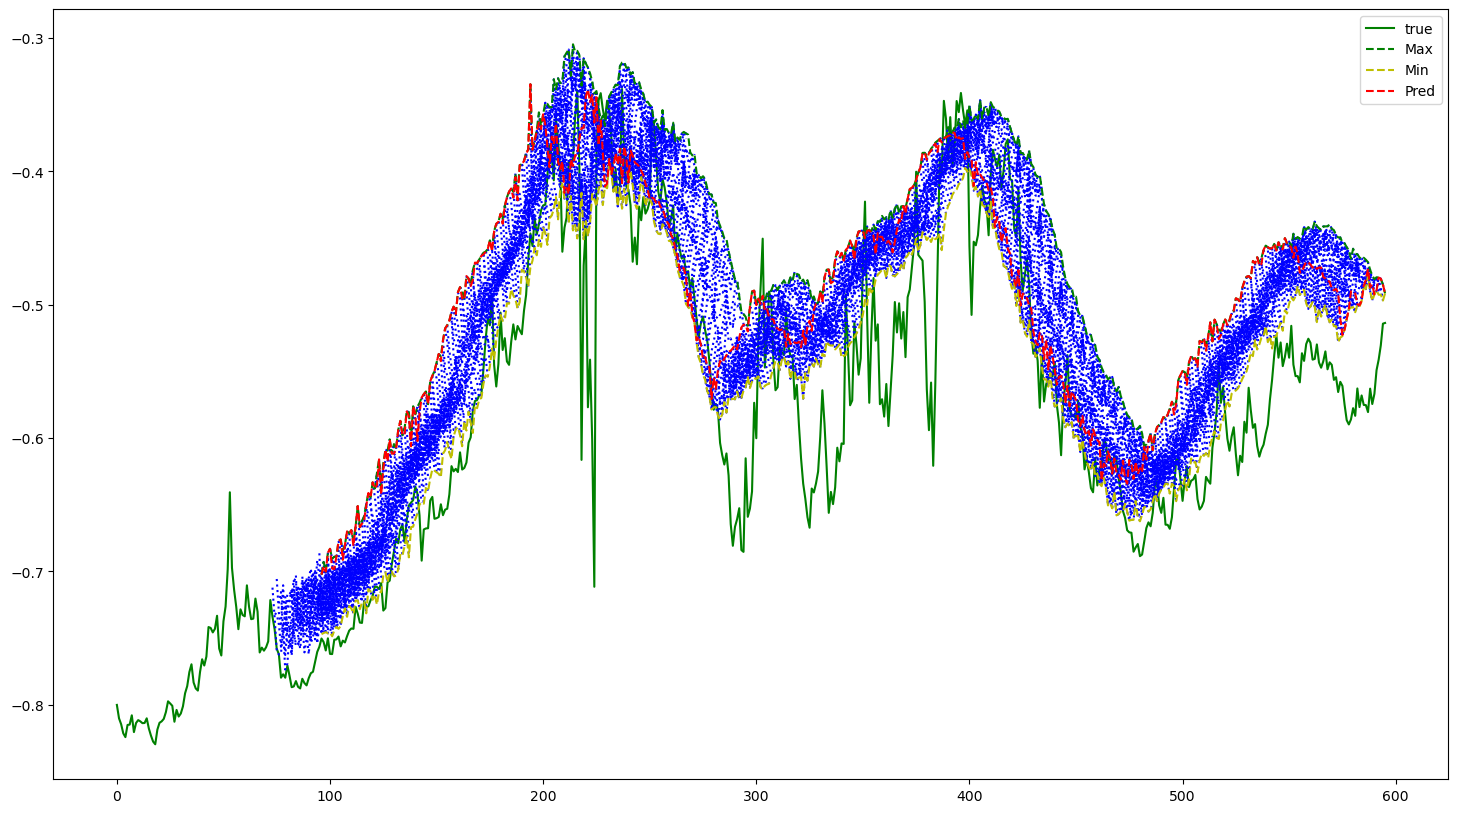

In [31]:

print(Mall.shape)

fig = plt.figure(figsize=(18,10))
plt.plot(range(0,fin), Xi[0:fin,sel_feature], 'g', label='true')
for i in range(1,forecast+1):
    plt.plot(range(72+i,72+24+i),Mall[i,:,sel_feature], 'b:')
    # plt.plot(range(1,25),Mall[2,:,6], 'y:', label='true')
    # plt.plot(range(2,26),Mall[3,:,6], 'g:', label='true')
    # plt.plot(range(3,27),Mall[4,:,6], 'r:', label='true')
    # plt.plot(range(4,28),Mall[5,:,6], 'v:', label='true')
    # plt.plot(range(0,28),Pia[48:48+29,6], 'r--', label='true')
# plt.plot(range(0,48),Xi[:48,6], 'b', label='true'
# plt.plot(range(47+forecast,Xi.shape[0]), Xi[47+forecast:,6], 'b')
# plt.plot(range(0,Xi.shape[0]),Xi[:,6], 'b', label='true')
plt.plot(range(96,Pimax.shape[0]),Pimax[96:,sel_feature], 'g--', label='Max')
plt.plot(range(96,Pimin.shape[0]),Pimin[96:,sel_feature], 'y--', label='Min')
# plt.plot(range(0,24+forecast-1),Pimin[48:48+24+forecast,6], 'b--', label='true')
plt.plot(range(96,Pia.shape[0]),Pia[96:,sel_feature], 'r--', label='Pred')

# plt.plot(range(48, fin),Pia[48:fin,feat], 'r--', label="Predicted");
# plt.plot(range(48, fin),Pimax[48:fin,feat], 'r:', label="P max");
# plt.plot(range(48, fin),Pimin[48:fin,feat], 'b:', label="P min");
# plt.plot(range(0,49),x_[0:49,feat], label="Training");
# plt.plot(range(48,fin-23),x_[48:fin-23,feat], 'g', label="Réel Passé");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:
import pandas as pd
print(PCia[:,6].shape, fin)
l = tf.concat([PCimax[None,:,6],PCimin[None,:,6]],axis=0)
print(l.shape)
# df = pd.DataFrame(data=[np.transpose(x_[:,6]),np.transpose(PCia[:,6]),np.transpose(PCimax[:,6]),np.transpose(PCimin[:,6])]) #, columns=['X','Y','Max','Min'])
# df = pd.DataFrame({'Y':(x_[:,6]), 'Pred':PCia[:,6],'Max':PCimax[:,6], 'Min':PCimin[:,6], 'Grp':l[0,:]})
# dfGrp=df.groupby(['Max','Min']).agg({'val','sum'})
# print(df.info())
# print(dfGrp)
fig = plt.figure(figsize=(18,10))
plt.ylim(v_min, v_max )
# plt.plot(range(48, fin),Pi[48:fin,feat], 'r--', label="Predicted");
# plt.plot(range(48, fin),PCia[48:fin,feat], 'r--', label="Predicted");
# sns.lineplot(x=range(0,fin),y="Pred", data=df, hue=dfGrp); #,hue=PCimax[:,6]);
plt.plot(range(0, fin),PCimax[0:fin,feat], 'r:', label="P max");
plt.plot(range(0, fin),PCimin[0:fin,feat], 'b:', label="P min");
plt.fill_between(x=range(0,fin), y1=PCimax[:,6], y2=PCimin[:,6], alpha=0.10, color='tab:orange')
plt.plot(range(0,49),x_[0:49,feat], label="Training");
plt.plot(range(48,fin-23),x_[48:fin-23,feat], 'g', label="Réel Passé");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:
settings

In [379]:
from pickle import dump
with open('./scaler/scaler.sav', 'wb') as file:
    dump(myExpFct.dataFct.scalerData, file)

with open('./settings/settings.sav', 'wb') as file:
    dump(settings, file)

